# Task 5: Sales Data Analysis
**Internship:** Synent Technologies – Data Science Internship  
**Dataset:** Superstore Sales Dataset  
**Tools:** Python, Pandas, Matplotlib, Seaborn  
**By:** Sneha Agarwal

## Objective
Analyze business performance through monthly revenue trends,
top-selling products, and profit analysis.

## Step 1: Load Dataset

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

uploaded = files.upload()
df = pd.read_csv('Sample - Superstore.csv', encoding='windows-1252')

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Saving Sample - Superstore.csv to Sample - Superstore.csv
Shape: (9994, 21)
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Step 2: Data Overview

In [4]:
print("=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Data Types ===")
print(df.dtypes)
print("\n=== Basic Statistics ===")
print(df.describe())

=== Missing Values ===
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

=== Data Types ===
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

=== B

## Step 3: Monthly Revenue Trend

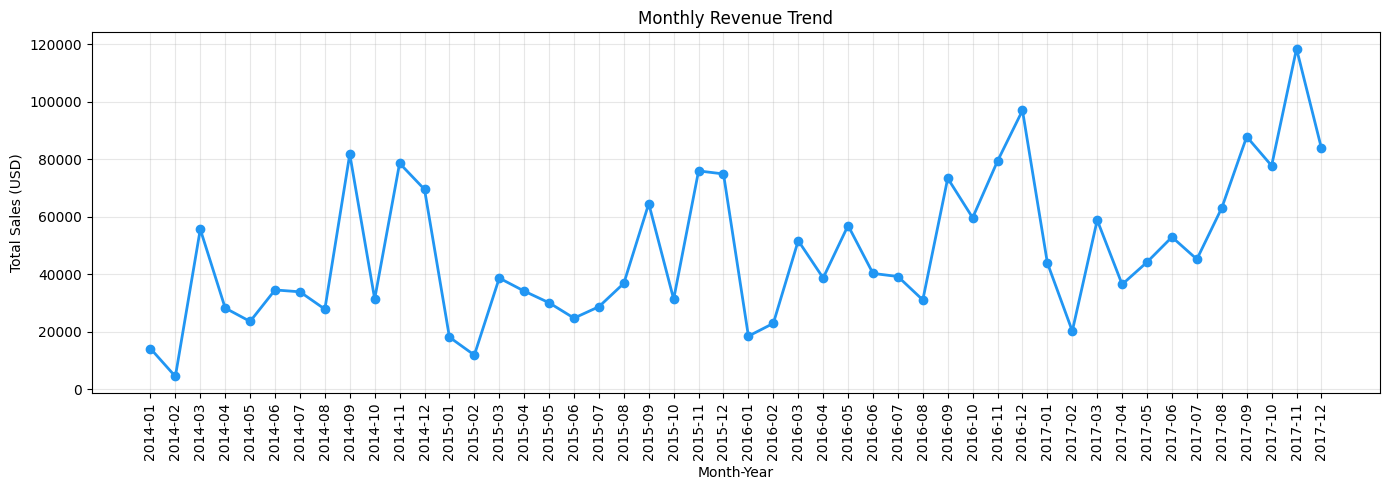

In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month-Year'] = df['Order Date'].dt.to_period('M')

monthly_sales = df.groupby('Month-Year')['Sales'].sum().reset_index()
monthly_sales['Month-Year'] = monthly_sales['Month-Year'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['Month-Year'], monthly_sales['Sales'], marker='o', color='#2196F3', linewidth=2)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month-Year')
plt.ylabel('Total Sales (USD)')
plt.xticks(rotation=90)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 4: Top 10 Best Selling Products

/tmp/ipykernel_1566/3569642321.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='Blues_r')


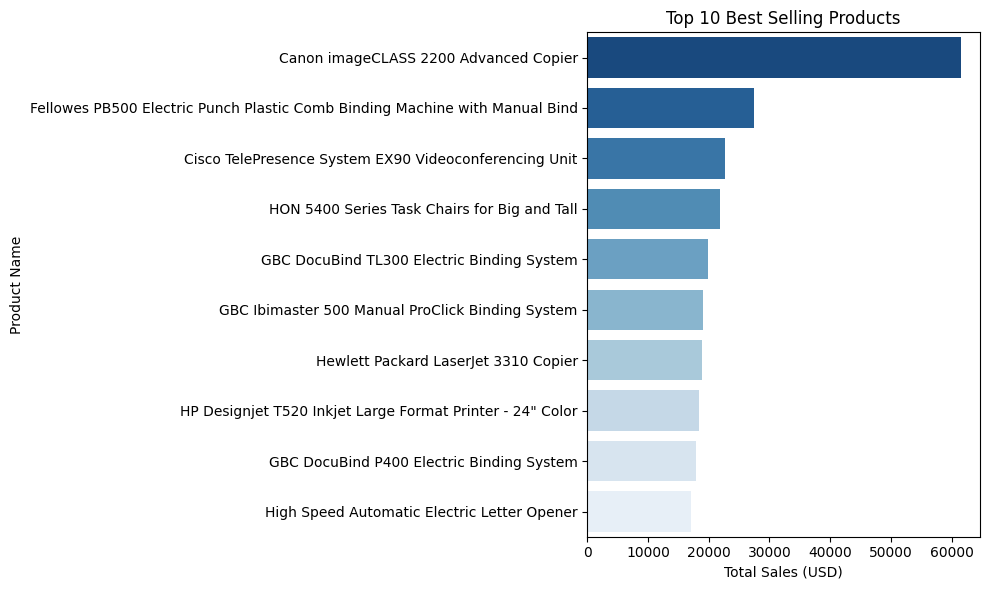

In [6]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette='Blues_r')
plt.title('Top 10 Best Selling Products')
plt.xlabel('Total Sales (USD)')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

## Step 5: Sales vs Profit by Category

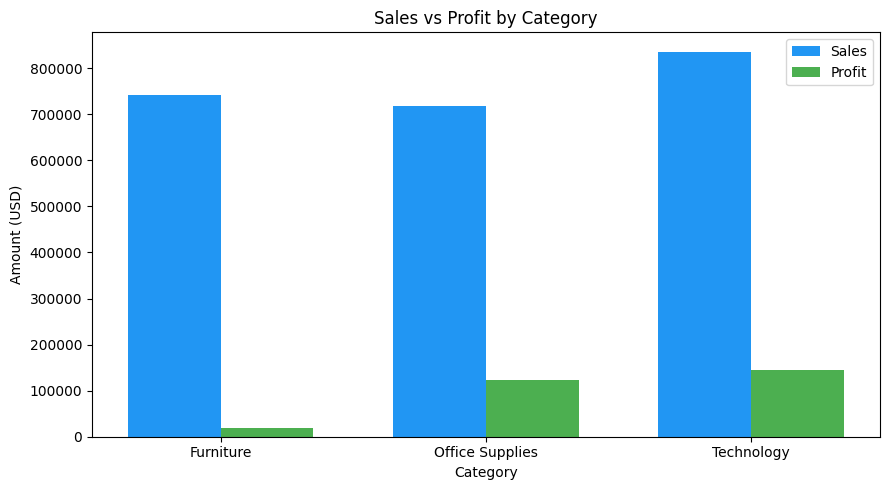

In [7]:
category_profit = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()

x = range(len(category_profit))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar([i - width/2 for i in x], category_profit['Sales'], width, label='Sales', color='#2196F3')
plt.bar([i + width/2 for i in x], category_profit['Profit'], width, label='Profit', color='#4CAF50')
plt.xticks(x, category_profit['Category'])
plt.title('Sales vs Profit by Category')
plt.xlabel('Category')
plt.ylabel('Amount (USD)')
plt.legend()
plt.tight_layout()
plt.show()

## Step 6: Top 10 States by Sales

/tmp/ipykernel_1566/1220032334.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_states.values, y=top_states.index, palette='Greens_r')


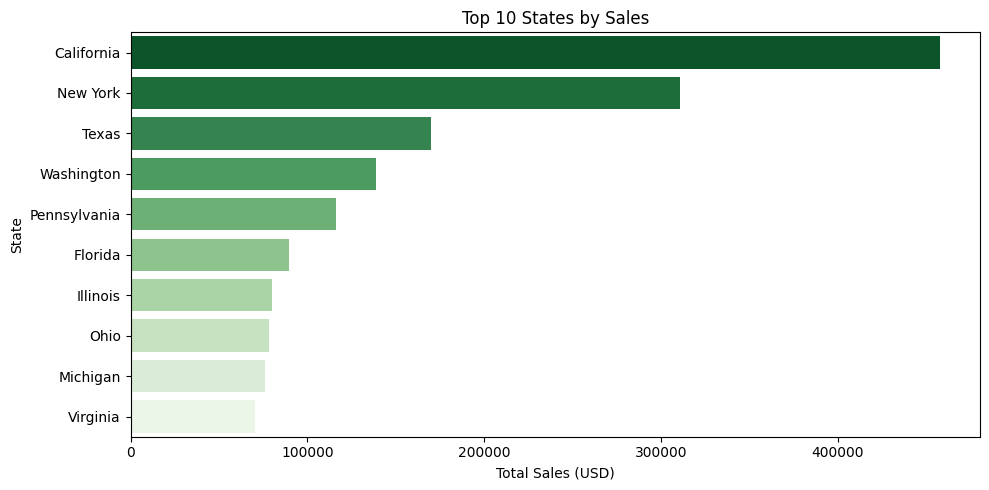

In [8]:
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_states.values, y=top_states.index, palette='Greens_r')
plt.title('Top 10 States by Sales')
plt.xlabel('Total Sales (USD)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

## Step 7: Sub-Category Profit Analysis

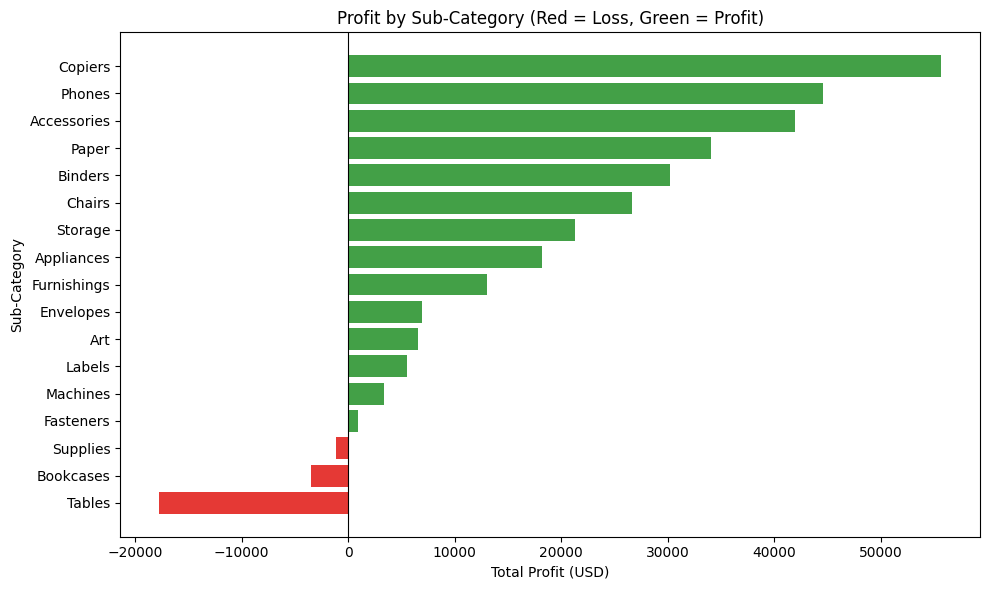

In [9]:
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()

colors = ['#E53935' if x < 0 else '#43A047' for x in subcat_profit.values]

plt.figure(figsize=(10, 6))
plt.barh(subcat_profit.index, subcat_profit.values, color=colors)
plt.title('Profit by Sub-Category (Red = Loss, Green = Profit)')
plt.xlabel('Total Profit (USD)')
plt.ylabel('Sub-Category')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## Step 8: Key Business Insights

In [10]:
print("=== KEY BUSINESS INSIGHTS ===")
print(f"\n1. Total Revenue: ${df['Sales'].sum():,.2f}")
print(f"2. Total Profit: ${df['Profit'].sum():,.2f}")
print(f"3. Profit Margin: {(df['Profit'].sum()/df['Sales'].sum()*100):.2f}%")
print(f"4. Top Selling Category: {df.groupby('Category')['Sales'].sum().idxmax()}")
print(f"5. Most Profitable Category: {df.groupby('Category')['Profit'].sum().idxmax()}")
print(f"6. Top State by Sales: {df.groupby('State')['Sales'].sum().idxmax()}")
print(f"7. Most Loss-Making Sub-Category: {df.groupby('Sub-Category')['Profit'].sum().idxmin()}")
print(f"8. Best Sales Month: {df.groupby('Month-Year')['Sales'].sum().idxmax()}")

=== KEY BUSINESS INSIGHTS ===

1. Total Revenue: $2,297,200.86
2. Total Profit: $286,397.02
3. Profit Margin: 12.47%
4. Top Selling Category: Technology
5. Most Profitable Category: Technology
6. Top State by Sales: California
7. Most Loss-Making Sub-Category: Tables
8. Best Sales Month: 2017-11
